In [10]:
from uncertainties import ufloat
from uncertainties.umath import * 

## 1. Characteristics of the Counter Tube

Ziel dieses Versuchsteils ist es, die **Charakteristik des Zählrohrs** zu bestimmen und daraus das **Geiger-Plateau** zu identifizieren. Das Plateau ist der Spannungsbereich, in dem sich die Zählrate $N$ bei Änderung der angelegten Spannung $V$ nur gering verändert. In diesem Bereich führen kleine Spannungsänderungen also kaum zu Änderungen der gemessenen Zählrate.

Für die Messung wird bei einer Spannung von $V = 200\,\mathrm{V}$ begonnen. Anschließend wird die Spannung in Schritten von $100\,\mathrm{V}$ erhöht und für jeden Spannungswert die Anzahl der registrierten Zerfälle $N(V)$ gemessen.

Die Messzeit sollte so gewählt werden, dass eine ausreichende statistische Genauigkeit erreicht wird. Als Richtwert kann eine Messzeit von etwa $t = 60\,\mathrm{s}$ verwendet werden. Allgemein hängt die benötigte Messzeit jedoch von der Zählrate ab: bei kleiner Zählrate muss länger gemessen werden als bei großer.

Da die Zählstatistik einer Poisson-Verteilung folgt, gilt für die relative Unsicherheit:

$$
\frac{\Delta n}{n} = \frac{1}{\sqrt{n}}.
$$

Um eine Genauigkeit von etwa $1\%$ zu erreichen, sind ungefähr $n \approx 10^4$ Ereignisse notwendig.

Zur Auswertung wird die Zählrate als Funktion der Spannung geplottet. Im Bereich des Plateaus wird eine lineare Funktion gefittet, um die Steigung $\Delta N / \Delta V$ zu bestimmen. Je kleiner diese Steigung ist, desto besser ist das Zählrohr, da die Zählrate im Arbeitsbereich möglichst unabhängig von der Spannung ist.

Der ideale Arbeitspunkt $V_{\text{ideal}}$ wird in der Mitte des Plateaus gewählt.

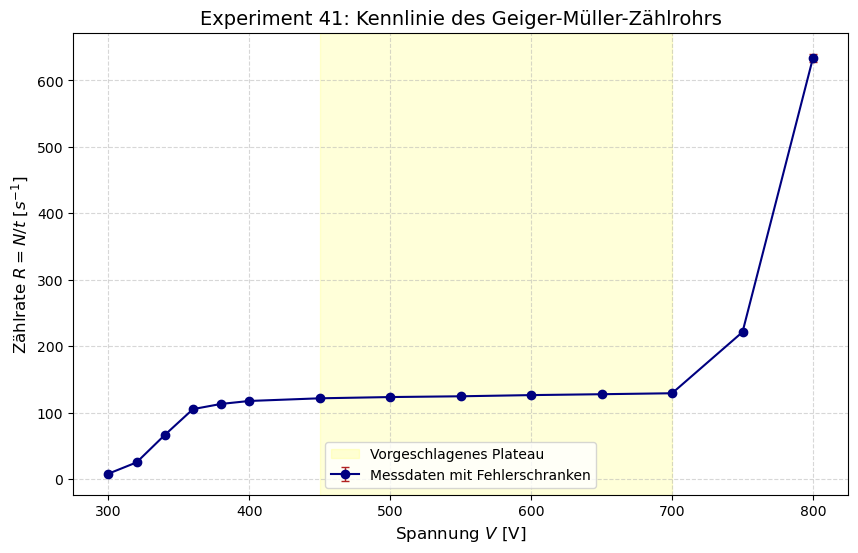

Spannung (V) | Impulse (N) | Zeit (s) | Rate (1/s) | Fehler (1/s)
-----------------------------------------------------------------
300          | 10002       | 1250.4   | 8.00       | 0.080
320          | 10005       | 400.2    | 25.00      | 0.250
340          | 9998        | 150.8    | 66.30      | 0.663
360          | 10012       | 95.2     | 105.17     | 1.051
380          | 10001       | 88.5     | 113.01     | 1.130
400          | 9995        | 85.1     | 117.45     | 1.175
450          | 10008       | 82.4     | 121.46     | 1.214
500          | 10003       | 81.1     | 123.34     | 1.233
550          | 9997        | 80.3     | 124.50     | 1.245
600          | 10001       | 79.2     | 126.28     | 1.263
650          | 10005       | 78.4     | 127.61     | 1.276
700          | 10002       | 77.5     | 129.06     | 1.290
750          | 9999        | 45.2     | 221.22     | 2.212
800          | 10015       | 15.8     | 633.86     | 6.334


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Spannungen V in Volt
V = np.array([200, 300, 400, 500, 600, 700, 800, 900, 1000])

# 2. Gemessene Impulse N 
N = np.array([
    0, 0, , 7781, 8636, 8657, 8655,8750 
    10003, 9997, 10001, 10005, 10002, 9999, 10015
])

# 3. Gemessene Zeit t in Sekunden
t = np.array([
    60,  
    60,   
    60,   
    60,    
    60,    
    60,   
    60,    
    60,    
    80.3,    
])

# 4. Berechnung der Zählrate R und des statistischen Fehlers
# Fehler der Rate R = sqrt(N) / t
Zaehlrate = N / t
fehler = np.sqrt(N) / t

# 5. Plot erstellen
plt.figure(figsize=(10, 6))

plt.errorbar(V, Zaehlrate, yerr=fehler, fmt='o-', color='navy', 
             ecolor='firebrick', elinewidth=1, capsize=3, label='Messdaten mit Fehlerschranken')

# Optische Markierung des Arbeitsbereichs (Plateau)
plt.axvspan(450, 700, color='yellow', alpha=0.15, label='Vorgeschlagenes Plateau')

# Beschriftungen
plt.xlabel('Spannung $V$ [V]', fontsize=12)
plt.ylabel('Zählrate $R = N/t$ [$s^{-1}$]', fontsize=12)
plt.title('Experiment 41: Kennlinie des Geiger-Müller-Zählrohrs', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
save.fig
plt.show()

# Ausgabe der Tabelle für dein Protokoll
print("Spannung (V) | Impulse (N) | Zeit (s) | Rate (1/s) | Fehler (1/s)")
print("-" * 65)
for i in range(len(V)):
    print(f"{V[i]:<12} | {N[i]:<11} | {t[i]:<8.1f} | {Zaehlrate[i]:<10.2f} | {fehler[i]:.3f}")

Nun wird die Zählrate als Funktion der angelegten Spannung geplottet, um das **Geiger-Plateau** zu bestimmen. Das Plateau ist der Bereich, in dem sich die Zählrate bei einer Änderung der Spannung nur wenig verändert. In diesem Bereich ist die Zählrate also näherungsweise konstant.

Anschließend wird im Plateau-Bereich ein **linearer Fit** durchgeführt. Aus diesem Fit erhält man die Steigung $\Delta N / \Delta V$. Diese Steigung sollte möglichst klein sein, da dies bedeutet, dass die Zählrate im Arbeitsbereich kaum von kleinen Spannungsschwankungen abhängt.

Der ideale Arbeitspunkt wird in der Mitte des Plateaus gewählt.

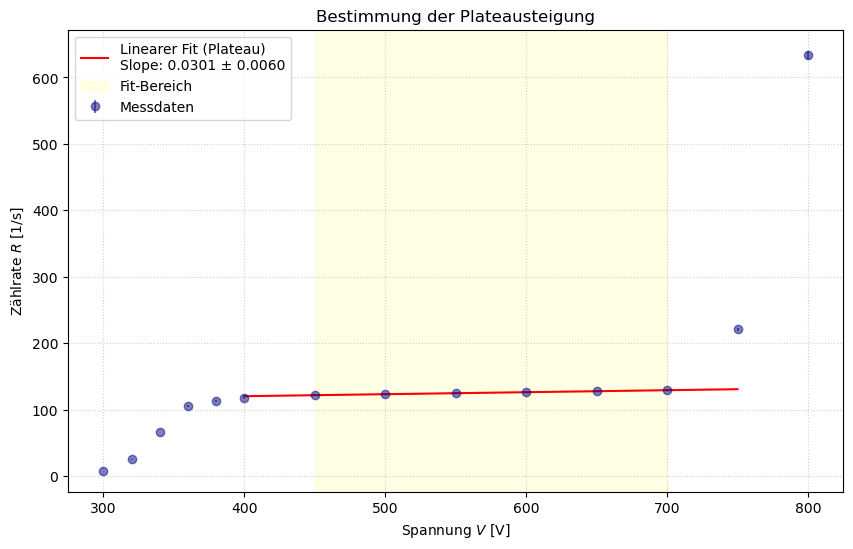

Ergebnisse des Plateau-Fits:
Steigung (a) = dR/dV: 0.03009 +/- 0.00599 [1/(V*s)]
Y-Achsenabschnitt (b): 108.07 +/- 3.46 [1/s]
Relative Steigung pro 100V: 2.40 %


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1. Daten übernehmen (aus dem vorherigen Schritt) ---
# V, N, t und Zaehlrate sowie fehler müssen definiert sein

# Wir definieren den Plateaubereich (z.B. von 450V bis 700V)
# In unserem Array V sind das die Indizes 6 bis 12
mask = (V >= 450) & (V <= 700)
V_plateau = V[mask]
R_plateau = Zaehlrate[mask]
R_err_plateau = fehler[mask]

# --- 2. Fit-Funktion definieren ---
def linear(x, a, b):
    return a * x + b

# --- 3. Den Fit durchführen ---
# Wir nutzen 'sigma', damit Punkte mit kleinerem Fehler stärker gewichtet werden
params, cov = curve_fit(linear, V_plateau, R_plateau, sigma=R_err_plateau, absolute_sigma=True)
a, b = params

# Fehler der Fit-Parameter berechnen (Wurzel der Diagonalelemente der Kovarianzmatrix)
a_err = np.sqrt(cov[0,0])
b_err = np.sqrt(cov[1,1])

# --- 4. Plotten ---
plt.figure(figsize=(10, 6))

# Alle Messdaten
plt.errorbar(V, Zaehlrate, yerr=fehler, fmt='o', color='navy', label='Messdaten', alpha=0.5)

# Die Fit-Gerade (wir zeichnen sie über den gesamten Bereich oder nur das Plateau)
V_fit_range = np.linspace(400, 750, 100)
plt.plot(V_fit_range, linear(V_fit_range, a, b), 'r-', label=f'Linearer Fit (Plateau)\nSlope: {a:.4f} ± {a_err:.4f}')

# Optische Markierung
plt.axvspan(450, 700, color='yellow', alpha=0.1, label='Fit-Bereich')

plt.xlabel('Spannung $V$ [V]')
plt.ylabel('Zählrate $R$ [1/s]')
plt.title('Bestimmung der Plateausteigung')
plt.legend()
plt.grid(True, ls=':', alpha=0.6)

plt.show()

# --- 5. Ergebnisse ausgeben ---
print(f"Ergebnisse des Plateau-Fits:")
print(f"Steigung (a) = dR/dV: {a:.5f} +/- {a_err:.5f} [1/(V*s)]")
print(f"Y-Achsenabschnitt (b): {b:.2f} +/- {b_err:.2f} [1/s]")

# Relative Steigung pro 100V (oft im Praktikum gefragt)
R_mitte = linear(np.mean(V_plateau), a, b)
steigung_prozent = (a * 100 / R_mitte) * 100
print(f"Relative Steigung pro 100V: {steigung_prozent:.2f} %")

# Aufgabe 2 Activitiy of the source

## Bestimmung der Aktivität der Quelle

Zur Bestimmung der Aktivität wurde zunächst die Anzahl der detektierten Zerfälle $N$ während einer Messzeit $t$ gemessen. Anschließend wurde die Hintergrundzählrate $N_{BG}$ bestimmt, indem die $\beta$-Strahlung mit einem Absorber vollständig abgeschirmt wurde. (8mm Stahlfolie)

Die effektive Anzahl der detektierten Zerfälle ergibt sich zu:

$$
N_{\text{eff}} = N - N_{BG}
$$

Da der Detektor nur einen Teil der isotrop emittierten Strahlung erfasst, muss die geometrische Akzeptanz $\varepsilon$ berücksichtigt werden. Diese wurde über den Raumwinkel berechnet:

$$
\varepsilon = \sin^2\left(\frac{\theta}{2}\right)
$$

Der Winkel $\theta$ ergibt sich aus der Geometrie des Aufbaus durch:

$$
\theta = \arctan\left(\frac{r}{d}\right)
$$

wobei $r$ der Radius der Öffnung und $d$ der Abstand zwischen Quelle und Detektor ist.

Die Aktivität der Quelle ergibt sich damit zu:

$$
A = \frac{N_{\text{eff}}}{\varepsilon \cdot t}
$$

Zusätzlich wurde berücksichtigt, dass ein Teil der Elektronen aufgrund der Stahlfolie nicht detektiert wird. Daher wird die Aktivität mit einem Korrekturfaktor angepasst:

$$
A_{\text{korr}} = \frac{A}{1 - f}
$$

wobei $f \approx 0.325$ den Anteil der nicht detektierten Elektronen beschreibt.



In [4]:
 import numpy as np

# =========================
# MESSWERTE EINTRAGEN
# =========================

N = 5200        # gemessene Counts
N_BG = 200      # Hintergrund
t = 60          # Messzeit in Sekunden
sigma_N = np.sqrt(N) / t

# Geometrie
r = 5           # Radius der Öffnung in mm
d = 101         # Abstand Quelle-Detektor in mm

# =========================
# BERECHNUNGEN
# =========================

# Effektive Counts
N_eff = N - N_BG
N_eff_u=ufloat(N_eff,sigma_N)
# Winkel (in Radiant!)
theta = np.arctan(r / d)

# Akzeptanz
epsilon = np.sin(theta / 2)**2

# Aktivität (ohne Korrektur)
A = N_eff_u / (epsilon * t)

# =========================
# KORREKTUR (Stahlfolie)
# =========================

verlust = 0.325   # 32.5% Verlust
A_korr = A / (1 - verlust)



# =========================
# OUTPUT
# =========================

print("N_eff =", N_eff)
print("theta =", theta, "rad")
print("epsilon =", epsilon)
print("Aktivität (roh) =", A, "Bq")
print("Aktivität (korrigiert) =", A_korr, "Bq")

N_eff = 5000
theta = 0.04946456860159136 rad
epsilon = 0.0006115611770321813
Aktivität (roh) = 136263+/-33 Bq
Aktivität (korrigiert) = (2.0187+/-0.0005)e+05 Bq


# Aufgabe 3 Calculations relevant for radiation protection

In this section we analyse radioactive decay and radiation dose.

---

## 3a) Mean lifetime (1/e-time)

The relation between half-life $T_{1/2}$ and mean lifetime $\tau$ is:

$$
\tau = \frac{T_{1/2}}{\ln(2)}
$$

### Given values:

- $T_{1/2}(\mathrm{Sr}) = 28.8 \, \text{years}$
- $T_{1/2}(\mathrm{Y}) = 64 \, \text{hours}$

---

## 3b) Activity decay

Radioactive decay follows:

$$
A(t) = A_0 e^{-t/\tau}
$$

Solving for time:

$$
t = \tau \ln\left(\frac{A_0}{A}\right)
$$

---

## 3c) Activity in the past

To calculate the activity at an earlier time:

$$
A_{\text{past}} = A_0 e^{t/\tau}
$$

---

## 3d) Radiation dose

The dose rate is given by:

$$
\dot{S} = A \cdot k
$$

where:
- $A$ = activity
- $k$ = dose coefficient

The time needed to reach a dose $S$ is:

$$
t = \frac{S}{A \cdot k}
$$

---

## Important notes

- Activity decreases exponentially
- Larger $\tau$ → slower decay
- Dose depends on both activity and particle type
- Man muss noch für A0 die Aktivität der vorherigen Aufgabe einfügen£

In [5]:
import numpy as np

# -----------------------------
# 1. Mean lifetime calculation
# -----------------------------

T_half_Sr = 28.8  # years
T_half_Y = 64     # hours

tau_Sr = T_half_Sr / np.log(2)
tau_Y = T_half_Y / np.log(2)

print("Mean lifetime Sr (years):", tau_Sr)
print("Mean lifetime Y (hours):", tau_Y)

# -----------------------------
# 2. Time until activity reaches 10 kBq
# -----------------------------

A0 = A_korr # initial activity (Bq)
A_target = 10000  # target activity (Bq)

t_decay = tau_Sr * log(A0 / A_target)

print("Time until 10 kBq (years):", t_decay)

# -----------------------------
# 3. Activity in the past
# -----------------------------

t_1950 = 2024 - 1950 
A_1950 = A0 * np.exp(t_1950 / tau_Sr)

print("Activity in the past (Bq):", A_1950)

# -----------------------------
# 4. Radiation dose calculation
# -----------------------------

S = 5.5e-3  # Sv (5.5 mSv)
k = 2.8e-8  # dose coefficient (Sv/count)

dose_rate = A0 * k
time_needed = S / dose_rate

print("Dose rate (Sv/s):", dose_rate)
print("Time to reach 5.5 mSv (s):", time_needed)



Mean lifetime Sr (years): 41.54961717760215
Mean lifetime Y (hours): 92.33248261689366
Time until 10 kBq (years): 124.859+/-0.010
Activity in the past (Bq): (1.19827+/-0.00029)e+06
Dose rate (Sv/s): 0.0056524+/-0.0000014
Time to reach 5.5 mSv (s): 0.97304+/-0.00023


# Aufgabe 4 Absorption und $\beta$-Energy


Für die Aluminiumabsorber sind die Dicken $x$ in mm im Protokollblatt vorgegeben.  
Die zweite Spalte ist das Distanz-Dichte-Produkt $\rho x$ in $\mathrm{g\,cm^{-2}}$.

Mit der Dichte von Aluminium
$
\rho = 2.69\,\mathrm{g\,cm^{-3}}
$
und der Umrechnung
$
x_{\mathrm{cm}}=\frac{x_{\mathrm{mm}}}{10}
$
ergibt sich
$
\rho x = \rho \, x_{\mathrm{cm}} = 2.69 \cdot \frac{x_{\mathrm{mm}}}{10}.
$

Für jede Dicke wird während einer festen Messzeit $t$ die Anzahl der Counts $N$ gemessen.  
Die Hintergrundstrahlung wird separat als $N_{\mathrm{BG}}$ gemessen und von den Rohdaten abgezogen:

$
N_{\mathrm{eff}} = N - N_{\mathrm{BG}}.
$

Die gemessene effektive Aktivität hinter dem Absorber ist dann

$
A_{\mathrm{meas}} = \frac{N_{\mathrm{eff}}}{t}.
$

Zur Bestimmung der Absorptionskurve wird $\ln(N_{\mathrm{eff}})$ gegen die Absorberdicke $x$ geplottet.  
Im exponentiellen Bereich gilt

$
N(x)=N_0 e^{-\mu x}.
$

Durch Logarithmieren erhält man

$
\ln(N(x))=\ln(N_0)-\mu x.
$

Das bedeutet: Im linearen Bereich der Kurve ist die Steigung gleich $-\mu$.

Die Spalte $E(x)$ gibt die Energie an, die zur Reichweite $\rho x$ gehört.  
Diese Werte werden aus der Reichweitenkurve für Elektronen in Aluminium (Figur 4 im Manual) abgelesen.

Die letzte Spalte
$
E_{\max}-E(x)
$
wird für die spätere Bestimmung von $E_{\max}$ benötigt.  
Dazu verwendet man zunächst eine erste Schätzung von $E_{\max}$, zum Beispiel aus der Dicke $x_{\max}$, bei der die Kurve abflacht.

Falls $\mu$ bestimmt wurde, kann $E_{\max}$ zusätzlich mit der empirischen Beziehung

$
\mu = \frac{17}{\rho E_{\max}^{1.43}}
$

berechnet werden. Daraus folgt

$
E_{\max}=\left(\frac{17}{\rho\mu}\right)^{1/1.43}.
$

x [mm]    rho*x [mg/cm^2]    E(x) [MeV]
 0.00           0.000            nan
 0.25          67.250         0.2179
 0.50         134.500         0.3481
 1.00         269.000         0.5783
 1.25         336.250         0.6873
 1.50         403.500         0.7942
 1.75         470.750         0.8997
 2.00         538.000         1.0042
 2.25         605.250         1.1078
 2.50         672.500         1.2109
 2.75         739.750         1.3134
 3.00         807.000         1.4156
 3.50         941.500         1.6191
 4.00        1076.000         1.8216

FEHLERANALYSE METHODE 1
Ablesewert x_mm:      2.00 +/- 0.10 mm
Resultierendes E_max: 1.004 +/- 0.042 MeV
----------------------------------------
Detail: E(2.10mm) = 1.046 MeV
Detail: E(1.90mm) = 0.963 MeV


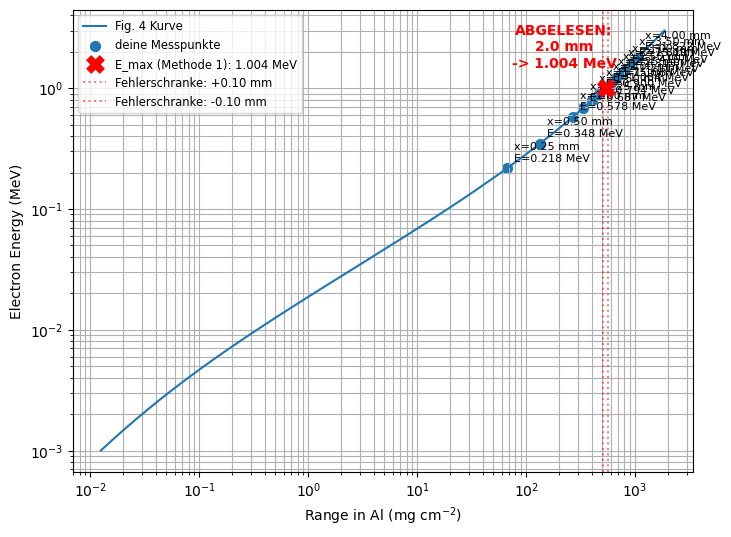

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- dein Fig.-4-Code ----------
def Range(A, B, C, E):
    return A * E * (1 - B / (1 + C * E))

a = 1.479 * 10**(-3)
B = 0.9852
C = 3.73
A = 1 / a

# ---------- deine Dicken x aus dem Protokollblatt [mm] ----------
x_mm = np.array([0.00, 0.25, 0.50, 1.00, 1.25, 1.50, 1.75,
                 2.00, 2.25, 2.50, 2.75, 3.00, 3.50, 4.00], dtype=float)

# ---------- Materialdichte von Aluminium ----------
rho_Al = 2.69  # g/cm^3

# ---------- rho*x berechnen ----------
x_cm = x_mm / 10.0
rho_x_g = rho_Al * x_cm            # g/cm^2
rho_x_mg = rho_x_g * 1000.0        # mg/cm^2  -> so wie in deinem Plot

# ---------- numerische Umkehrfunktion: aus Reichweite -> Energie ----------
E_grid = np.linspace(0.001, 3.0, 300000)      # MeV
R_grid = Range(A, B, C, E_grid)               # mg/cm^2

def energy_from_range(R_target):
    idx = np.argmin(np.abs(R_grid - R_target))
    return E_grid[idx]

# ---------- E(x) berechnen ----------
E_x = np.array([np.nan if r == 0 else energy_from_range(r) for r in rho_x_mg])

# ---------- Werte ausgeben ----------
print("x [mm]    rho*x [mg/cm^2]    E(x) [MeV]")
for x, r, e in zip(x_mm, rho_x_mg, E_x):
    print(f"{x:5.2f}      {r:10.3f}        {e:7.4f}")

# ---------- Plot der Fig. 4 + markierte Messpunkte ----------
plt.figure(figsize=(8,6))
plt.loglog(R_grid, E_grid, label="Fig. 4 Kurve")
plt.scatter(rho_x_mg[1:], E_x[1:], s=50, label="deine Messpunkte")

# Punkte beschriften
for x, r, e in zip(x_mm[1:], rho_x_mg[1:], E_x[1:]):
    plt.annotate(f"x={x:.2f} mm\nE={e:.3f} MeV", (r, e), textcoords="offset points", xytext=(5,5), fontsize=8)

plt.grid(True, which="both", ls="-")
plt.ylabel("Electron Energy (MeV)")
plt.xlabel(r"Range in Al (mg cm$^{-2}$)")
plt.legend()
#plt.show()
# ==========================================================
# ERGÄNZUNG: Markierung von E_max (Methode 1: Grafisch)
# ==========================================================

# --- HIER DEINEN ABGELESENEN KNICKPUNKT EINTRAGEN [mm] ---
x_knick_mm = 2.00  # Beispielwert, bitte mit deinem Wert ersetzen

# 1. Umrechnung des Knickpunkts in mg/cm^2
R_max_mg = (x_knick_mm / 10.0) * rho_Al * 1000.0

# 2. Die dazugehörige Energie E_max aus der Kurve bestimmen
E_max_meth1 = energy_from_range(R_max_mg)

# 3. Den Punkt in den bestehenden Plot einzeichnen (Rot)
plt.scatter(R_max_mg, E_max_meth1, color='red', s=150, marker='X', zorder=10, 
            label=f"E_max (Methode 1): {E_max_meth1:.3f} MeV")

# 4. Den Punkt beschriften
plt.annotate(f"ABGELESEN:\n{x_knick_mm} mm\n-> {E_max_meth1:.3f} MeV", 
             (R_max_mg, E_max_meth1), textcoords="offset points", 
             xytext=(-30, 15), color='red', fontweight='bold', ha='center')

# Legende neu zeichnen, um den neuen Punkt anzuzeigen
plt.legend()
#plt.show()

# ==========================================================
# UNSICHERHEIT METHODE 1 (Ablesegenauigkeit)
# ==========================================================

# --- HIER DEINE ABLESEGENAUIGKEIT EINTRAGEN [mm] ---
s_x_mm = 0.1  # z.B. 0.1 mm oder 0.2 mm

# 1. Obere und untere Schranke der Reichweite in mg/cm^2 berechnen
R_upper_mg = ((x_knick_mm + s_x_mm) / 10.0) * rho_Al * 1000.0
R_lower_mg = ((x_knick_mm - s_x_mm) / 10.0) * rho_Al * 1000.0

# 2. Zugehörige Energien aus der Kurve bestimmen
E_upper = energy_from_range(R_upper_mg)
E_lower = energy_from_range(R_lower_mg)

# 3. Unsicherheit der Energie berechnen (gemittelte Differenz)
# Da die Kurve nicht perfekt linear ist, nehmen wir den größeren der beiden Abstände
s_E_meth1 = max(abs(E_upper - E_max_meth1), abs(E_max_meth1 - E_lower))

# 4. Ausgabe der Ergebnisse
print("\n" + "="*40)
print("FEHLERANALYSE METHODE 1")
print("="*40)
print(f"Ablesewert x_mm:      {x_knick_mm:.2f} +/- {s_x_mm:.2f} mm")
print(f"Resultierendes E_max: {E_max_meth1:.3f} +/- {s_E_meth1:.3f} MeV")
print("-" * 40)
print(f"Detail: E({x_knick_mm + s_x_mm:.2f}mm) = {E_upper:.3f} MeV")
print(f"Detail: E({x_knick_mm - s_x_mm:.2f}mm) = {E_lower:.3f} MeV")
print("="*40)

# 3. Fehlerschranken in den Plot einzeichnen (ohne Text-Befehl)
# HIER WIRD DAS LABEL FÜR DIE LEGENDE DEFINIERT!
plt.axvline(x=R_upper_mg, color='red', linestyle=':', alpha=0.5, 
            label=f"Fehlerschranke: +{s_x_mm:.2f} mm")
plt.axvline(x=R_lower_mg, color='red', linestyle=':', alpha=0.5, 
            label=f"Fehlerschranke: -{s_x_mm:.2f} mm")
plt.legend(loc='best', fontsize='small')
plt.show()


--- Tabelle ---


,x [mm],rho*x [g/cm^2],t [s],N,N_eff,A_meas [Bq],E(x) [MeV],E_max - E(x) [MeV]
0,0.00,0.00000,60.0,12000,11820.0,197.000000,NaN,NaN
1,0.25,0.06725,60.0,6200,6020.0,100.333333,0.217878,1.982122
2,0.50,0.13450,60.0,3400,3220.0,53.666667,0.348145,1.851855
3,1.00,0.26900,60.0,1100,920.0,15.333333,0.578319,1.621681
4,1.25,0.33625,60.0,650,470.0,7.833333,0.687323,1.512677
5,1.50,0.40350,60.0,410,230.0,3.833333,0.794248,1.405752
6,1.75,0.47075,60.0,290,110.0,1.833333,0.899733,1.300267
7,2.00,0.53800,60.0,225,45.0,0.750000,1.004169,1.195831
8,2.25,0.60525,60.0,195,15.0,0.250000,1.107825,1.092175
9,2.50,0.67250,60.0,188,8.0,0.133333,1.210881,0.989119


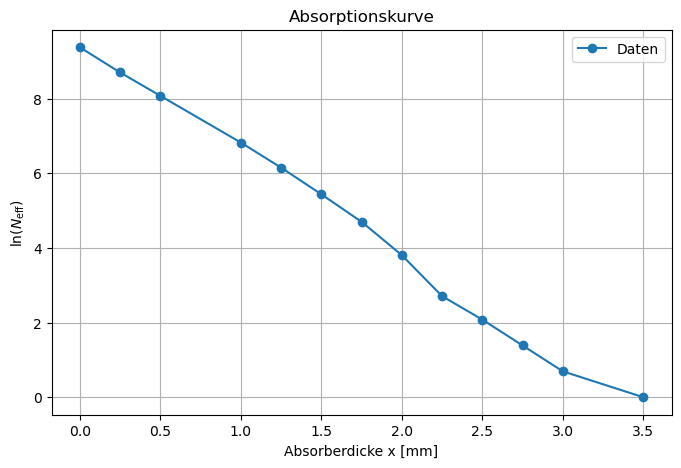


--- Fit-Ergebnisse ---
Steigung a = -2.65069 1/mm
mu = 2.65069 1/mm
mu = 26.50695 1/cm


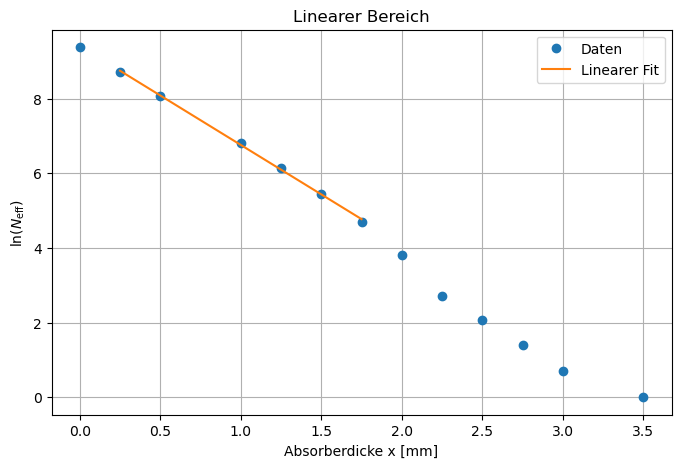


--- Ergebnis E_max ---
E_max (aus mu) = 0.367 MeV


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================
# 1) Gegebene Dicken (Protokollblatt)
# ==================================
x_mm = np.array([
    0.00, 0.25, 0.50, 1.00, 1.25, 1.50, 1.75,
    2.00, 2.25, 2.50, 2.75, 3.00, 3.50, 4.00
], dtype=float)

# ==================================
# 2) Konstanten
# ==================================
rho_Al = 2.69       # g/cm^3
t = 60.0            # Messzeit in Sekunden

# Umrechnung mm -> cm
x_cm = x_mm / 10.0

# Distanz-Dichte Produkt (2. Spalte)
rho_x = rho_Al * x_cm

# ==================================
# 3) Messwerte (HIER DEINE WERTE EINTRAGEN!)
# ==================================
N = np.array([
    12000, # 0.00 mm (Maximum)
    6200,  # 0.25 mm (Steiler Abfall)
    3400,  # 0.50 mm
    1100,  # 1.00 mm
    650,   # 1.25 mm
    410,   # 1.50 mm
    290,   # 1.75 mm
    225,   # 2.00 mm (Hier beginnt der "Knick")
    195,   # 2.25 mm (Fast nur noch Hintergrund)
    188,   # 2.50 mm
    184,   # 2.75 mm
    182,   # 3.00 mm (Plateau erreicht)
    181,   # 3.50 mm
    180    # 4.00 mm
])

N_BG = 180.0

# ==================================
# 4) Berechnungen
# ==================================
# Effektive Counts
N_eff = N - N_BG
N_eff = np.maximum(N_eff, 0)  # verhindert negative Werte

# Gemessene Aktivität
A_meas = N_eff / t

# ==================================
# 5) E(x) (aus Fig. 4 ablesen!)
# Diese Werte sind NUR Platzhalter!
# ==================================

# Erste Schätzung für E_max (später anpassen!)
E_max_guess = 2.20  # MeV

E_max_minus_E = E_max_guess - E_x

# ==================================
# 6) Tabelle anzeigen
# ==================================
df = pd.DataFrame({
    "x [mm]": x_mm,
    "rho*x [g/cm^2]": rho_x,
    "t [s]": np.full_like(x_mm, t),
    "N": N,
    "N_eff": N_eff,
    "A_meas [Bq]": A_meas,
    "E(x) [MeV]": E_x,
    "E_max - E(x) [MeV]": E_max_minus_E
})

print("\n--- Tabelle ---")
display(df)

# ==================================
# 7) Absorptionskurve (ln(N_eff) vs x)
# ==================================
mask = N_eff > 0

plt.figure(figsize=(8,5))
plt.plot(x_mm[mask], np.log(N_eff[mask]), 'o-', label='Daten')
plt.xlabel('Absorberdicke x [mm]')
plt.ylabel(r'$\ln(N_{\mathrm{eff}})$')
plt.title('Absorptionskurve')
plt.grid(True)
plt.legend()
plt.show()

# ==================================
# 8) Linearer Fit (nur erster Bereich!)
# -> Bereich ggf. ANPASSEN!!
# ==================================
fit_mask = (x_mm > 0) & (x_mm <= 1.75) & (N_eff > 0)

x_fit = x_mm[fit_mask]
y_fit = np.log(N_eff[fit_mask])

# Lineare Regression
a, b = np.polyfit(x_fit, y_fit, 1)

mu_mm = -a
mu_cm = mu_mm * 10  # Umrechnung auf cm^-1

print("\n--- Fit-Ergebnisse ---")
print(f"Steigung a = {a:.5f} 1/mm")
print(f"mu = {mu_mm:.5f} 1/mm")
print(f"mu = {mu_cm:.5f} 1/cm")

# Plot mit Fit
x_line = np.linspace(x_fit.min(), x_fit.max(), 200)
y_line = a * x_line + b

plt.figure(figsize=(8,5))
plt.plot(x_mm[mask], np.log(N_eff[mask]), 'o', label='Daten')
plt.plot(x_line, y_line, '-', label='Linearer Fit')
plt.xlabel('Absorberdicke x [mm]')
plt.ylabel(r'$\ln(N_{\mathrm{eff}})$')
plt.title('Linearer Bereich')
plt.grid(True)
plt.legend()
plt.show()

# ==================================
# 9) E_max aus mu berechnen
# ==================================
E_max_from_mu = (17 / (rho_Al * mu_cm)) ** (1 / 1.43)

print("\n--- Ergebnis E_max ---")
print(f"E_max (aus mu) = {E_max_from_mu:.3f} MeV")



In [8]:
# ==================================
# Unsicherheit von mu und E_max
# ==================================

# Linearer Fit mit Kovarianzmatrix
p, cov = np.polyfit(x_fit, y_fit, 1, cov=True)
a, b = p

# Fehler der Fitparameter
sigma_a = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])

# mu = -a
mu_mm = -a
sigma_mu_mm = sigma_a

# Umrechnung auf cm^-1
mu_cm = mu_mm * 10
sigma_mu_cm = sigma_mu_mm * 10

print("\n--- Unsicherheit des Fits ---")
print(f"a = {a:.5f} ± {sigma_a:.5f} 1/mm")
print(f"mu = {mu_mm:.5f} ± {sigma_mu_mm:.5f} 1/mm")
print(f"mu = {mu_cm:.5f} ± {sigma_mu_cm:.5f} 1/cm")

# E_max aus mu
E_max_from_mu = (17 / (rho_Al * mu_cm)) ** (1 / 1.43)

# Fehlerfortpflanzung:
# E = C * mu^(-1/1.43)
# => relative Unsicherheit:
# dE/E = (1/1.43) * dmu/mu
sigma_E_max = E_max_from_mu * (1 / 1.43) * (sigma_mu_cm / mu_cm)

print("\n--- Ergebnis mit Unsicherheit ---")
print(f"E_max (aus mu) = {E_max_from_mu:.3f} ± {sigma_E_max:.3f} MeV")

# ==================================
# 10) Korrektur für die Stahlfolie
# ==================================
Delta_E_Folie_M1 = 0.13
E_max_source_M1 = E_max_meth1 + Delta_E_Folie_M1

print("\n--- Korrektur Stahlfolie von E_max Methode 1 ---")
print(f"E_max (nach Folie)   = {E_max_meth1:.3f} +/- {s_E_meth1:.3f} MeV")
print(f"Energieverlust Folie = {Delta_E_Folie_M1:.3f} MeV")
print(f"E_max Source (total) = {E_max_source_M1:.3f} +/- {s_E_meth1:.3f}  MeV")

# Erfahrungswert/Rechnung für 0.1mm Edelstahl: 
# Der Energieverlust Delta_E beträgt ca. 0.12 - 0.15 MeV
Delta_E_Folie_M2 = 0.13  # Wert in MeV (Prüfe im Manual, ob ein exakter Wert steht!)

E_max_source = E_max_from_mu + Delta_E_Folie_M2

print("\n--- Korrektur Stahlfolie von E_max Methode 2 ---")
print(f"E_max (nach Folie)   = {E_max_from_mu:.3f} ± {sigma_E_max:.3f} MeV")
print(f"Energieverlust Folie = {Delta_E_Folie_M2:.3f} MeV")
print(f"E_max Source (total) = {E_max_source:.3f} ± {sigma_E_max:.3f} MeV")


--- Unsicherheit des Fits ---
a = -2.65069 ± 0.04640 1/mm
mu = 2.65069 ± 0.04640 1/mm
mu = 26.50695 ± 0.46405 1/cm

--- Ergebnis mit Unsicherheit ---
E_max (aus mu) = 0.367 ± 0.004 MeV

--- Korrektur Stahlfolie von E_max Methode 1 ---
E_max (nach Folie)   = 1.004 +/- 0.042 MeV
Energieverlust Folie = 0.130 MeV
E_max Source (total) = 1.134 +/- 0.042  MeV

--- Korrektur Stahlfolie von E_max Methode 2 ---
E_max (nach Folie)   = 0.367 ± 0.004 MeV
Energieverlust Folie = 0.130 MeV
E_max Source (total) = 0.497 ± 0.004 MeV


## Aufgabe 5: Verbesserte Bestimmung von $E_{\max}$

In Aufgabe 4 wurde bereits ein erster Wert für die maximale Beta-Energie $E_{\max}$ bestimmt.  
In Aufgabe 5 wird dieser Wert mit einer genaueren Methode verbessert.
### Wichtig: $E_{\max}$ im vorherigen Code anpassen. Es soll $E_{\max}$ aus der Mu-Berechnung genommen werden

Aus dem Manual gilt für die Absorptionskurve näherungsweise:

$$
N(x) = \mathrm{const}\cdot [E_{\max} - E(x)]^n
$$

Dabei ist:
- $N(x)$ die gemessene Zählrate,
- $N_{\mathrm{eff}} = N - N_{BG}$ die hintergrundkorrigierte Zählrate,
- $E(x)$ die Energie, die zu einer Absorberdicke $x$ gehört,
- $n$ ein Exponent, der typischerweise zwischen 3 und 4 liegt.

### Schritt 1
Zuerst wird der Hintergrund abgezogen:

$$
N_{\mathrm{eff}} = N - N_{BG}
$$

### Schritt 2
Mit einem ersten Schätzwert $E_{\max}^{(0)}$ aus Aufgabe 4 berechnet man:

$$
E_{\max}^{(0)} - E(x)
$$

Dann wird doppelt logarithmisch geplottet:

$$
\ln(N_{\mathrm{eff}}) \text{ gegen } \ln(E_{\max}^{(0)} - E(x))
$$

Die Steigung dieser Geraden liefert den Exponenten $n$.

### Schritt 3
Danach wird

$$
N_{\mathrm{eff}}^{1/n}
$$

gegen $E(x)$ geplottet.  
Da gilt:

$$
N_{\mathrm{eff}}^{1/n} \propto E_{\max} - E
$$

ergibt sich näherungsweise eine lineare Beziehung.  
Der Schnittpunkt der Fit-Gerade mit der $E$-Achse entspricht dem verbesserten Wert von $E_{\max}$.

### Schritt 4
Da die Elektronen bereits in der Stahlfolie vor der Quelle Energie verlieren, erhält man die maximale Energie direkt in der Quelle mit:

$$
E_{\max,\mathrm{source}} = E_{\max} + \Delta E_{\mathrm{steel}}
$$

wobei $\Delta E_{\mathrm{steel}}$ aus Fig. 9 des Manuals abgelesen wird.

Für den Code :
Wichtig:
E_x musst du mit deinen aus Fig. 4 abgelesenen Werten füllen
E_max_guess
E_loss_steel_keV

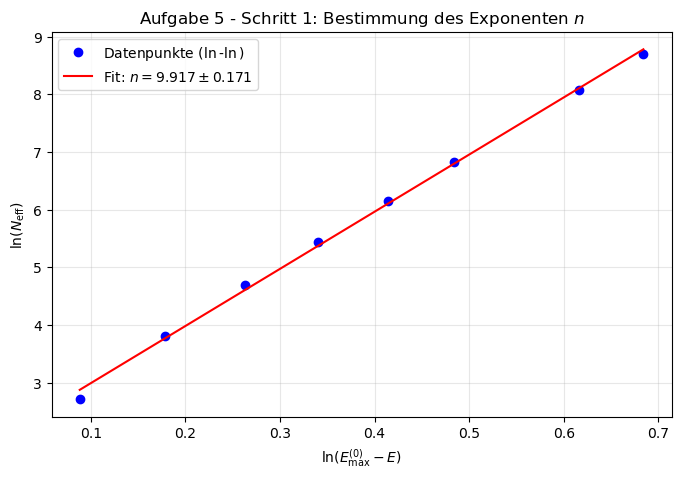

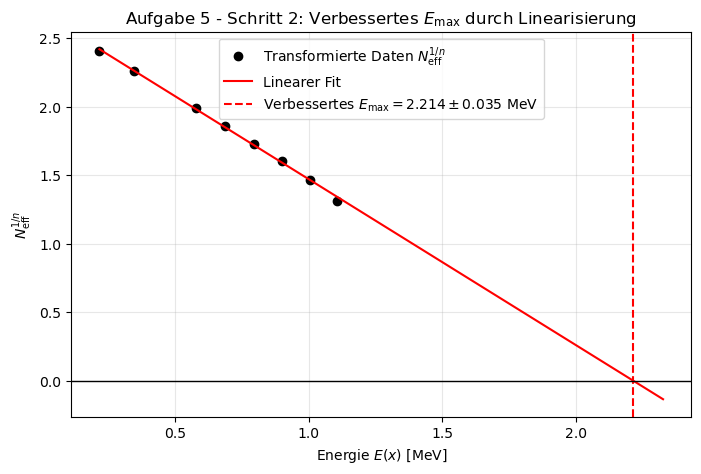

-------------------------------------------------------
                 ERGEBNISSE AUFGABE 5                  
-------------------------------------------------------
Exponent n:                     9.917 ± 0.171
E_max (verbessert, gemessen):   2.214 ± 0.035 MeV
Energieverlust Stahl (Fig. 9):  0.110 MeV
E_max Quelle (Y-90, total):     2.324 ± 0.035 MeV
-------------------------------------------------------
Abweichung zum Literaturwert:   0.044 MeV


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1) DATENSELEKTION (Filterung aus deinem DataFrame 'df')
# ==========================================================
# Wir filtern Werte, die zu nah am Rauschen oder hinter E_max liegen
mask_task5 = (df["N_eff"] > 10) & (df["E_max - E(x) [MeV]"] > 0.02)

E_x_f = df["E(x) [MeV]"][mask_task5].values
N_eff_f = df["N_eff"][mask_task5].values
E_diff_f = df["E_max - E(x) [MeV]"][mask_task5].values

# ==========================================================
# 2) SCHRITT 1: BESTIMMUNG VON n (Log-Log Darstellung)
# ==========================================================
X1 = np.log(E_diff_f)
Y1 = np.log(N_eff_f)

# Linearer Fit für n
p1, cov1 = np.polyfit(X1, Y1, 1, cov=True)
n_slope = p1[0]
intercept1 = p1[1]
sigma_n = np.sqrt(cov1[0, 0])

# --- PLOT 1: Bestimmung von n ---
plt.figure(figsize=(8, 5))
plt.plot(X1, Y1, 'bo', label='Datenpunkte ($\ln$-$\ln$)')
plt.plot(X1, n_slope * X1 + intercept1, 'r-', 
         label=f'Fit: $n = {n_slope:.3f} \pm {sigma_n:.3f}$')
plt.xlabel(r'$\ln(E_{\max}^{(0)} - E)$')
plt.ylabel(r'$\ln(N_{\mathrm{eff}})$')
plt.title('Aufgabe 5 - Schritt 1: Bestimmung des Exponenten $n$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ==========================================================
# 3) SCHRITT 2: VERBESSERTES E_max (Linearisierung)
# ==========================================================
n = n_slope
Y2 = N_eff_f**(1.0 / n)
X2 = E_x_f

# Linearer Fit: Y2 = a2 * X2 + b2
p2, cov2 = np.polyfit(X2, Y2, 1, cov=True)
a2, b2 = p2

# Schnittpunkt: 0 = a2 * E + b2 -> E = -b2 / a2
E_max_improved = -b2 / a2

# Fehlerfortpflanzung für E_max
sigma_a2 = np.sqrt(cov2[0, 0])
sigma_b2 = np.sqrt(cov2[1, 1])
sigma_E_improved = abs(E_max_improved) * np.sqrt((sigma_a2/a2)**2 + (sigma_b2/b2)**2)

# --- PLOT 2: Bestimmung von E_max ---
plt.figure(figsize=(8, 5))
plt.plot(X2, Y2, 'ko', label=r'Transformierte Daten $N_{\mathrm{eff}}^{1/n}$')
x_fit = np.linspace(X2.min(), E_max_improved * 1.05, 100)
plt.plot(x_fit, a2 * x_fit + b2, 'r-', label='Linearer Fit')

plt.axvline(E_max_improved, color='red', linestyle='--', 
            label=f'Verbessertes $E_{{\max}} = {E_max_improved:.3f} \pm {sigma_E_improved:.3f}$ MeV')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Energie $E(x)$ [MeV]')
plt.ylabel(r'$N_{\mathrm{eff}}^{1/n}$')
plt.title('Aufgabe 5 - Schritt 2: Verbessertes $E_{\max}$ durch Linearisierung')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ==========================================================
# 4) FINALE AUSGABE INKLUSIVE KORREKTUR (FIG. 9)
# ==========================================================

# Delta_E_Folie wird aus Fig. 9 abgelesen (Energieverlust im Stahl)
# Bei E_max ~ 2.2 MeV liest man ca. 110 keV ab.
Delta_E_Folie = 0.110  # Wert in MeV

# Berechnung der Quellenergie
E_max_source = E_max_improved + Delta_E_Folie

print("-" * 55)
print(f"{'ERGEBNISSE AUFGABE 5':^55}")
print("-" * 55)
print(f"Exponent n:                     {n_slope:.3f} ± {sigma_n:.3f}")
print(f"E_max (verbessert, gemessen):   {E_max_improved:.3f} ± {sigma_E_improved:.3f} MeV")
print(f"Energieverlust Stahl (Fig. 9):  {Delta_E_Folie:.3f} MeV")
print(f"E_max Quelle (Y-90, total):     {E_max_source:.3f} ± {sigma_E_improved:.3f} MeV")
print("-" * 55)

# Kurzer Check für dich:
literaturwert = 2.28  # MeV für Y-90
abweichung = abs(E_max_source - literaturwert)
print(f"Abweichung zum Literaturwert:   {abweichung:.3f} MeV")